In [1]:
import pandas as pd
import numpy as np

## Создадим свой DBSCAN

In [89]:
from sklearn.base import BaseEstimator, ClusterMixin
from collections import deque

class MyDBSCAN(BaseEstimator, ClusterMixin):
    def __init__(self, eps, min_samples, p = 2):
        self.eps = eps
        self.min_samples = min_samples
        self.p = p
        
    def minkowski_distance(self, first, second):
        return np.sum(np.abs(first - second) ** self.p) ** (1 / self.p)

    def find_all_neighbors(self, X):
        self.neighbors = [[i] for i in range(self.n_samples)]
        for i in range(self.n_samples):
            for j in range(i+1, self.n_samples):
                curr_dist = self.minkowski_distance(X[i], X[j])
                if curr_dist <= self.eps:
                    self.neighbors[i].append(j)
                    self.neighbors[j].append(i)
                    
    
    def fit(self, X):
        X = np.asarray(X)
        self.n_samples = X.shape[0]
        self.labels_ = np.full(self.n_samples, -1, dtype = int)
        
        self.find_all_neighbors(X)
        self.count_clusters = 0
        
        def mark_clusters(point):
            cores = deque()
            cores.append(point)
            while (cores):
                current_core = cores.popleft()
                visited.add(current_core)
                self.labels_[current_core] = self.count_clusters
                for neighbor in self.neighbors[current_core]:
                    if self.labels_[neighbor] == -1:
                        self.labels_[neighbor] = self.count_clusters
                        if len(self.neighbors[neighbor]) >= self.min_samples:
                            cores.append(neighbor)
            
        self.all_cores = deque(i for i in range(self.n_samples) if len(self.neighbors[i])>= self.min_samples)
        visited = set()
        while self.all_cores:
            core_num = self.all_cores.popleft()
            if core_num in visited or self.labels_[core_num] != -1:
                continue
            mark_clusters(core_num)
            self.count_clusters += 1
            
        return self
    
    def fit_predict(self, X):
        self.fit(X)
        return self.labels_

## Сравним качество работы

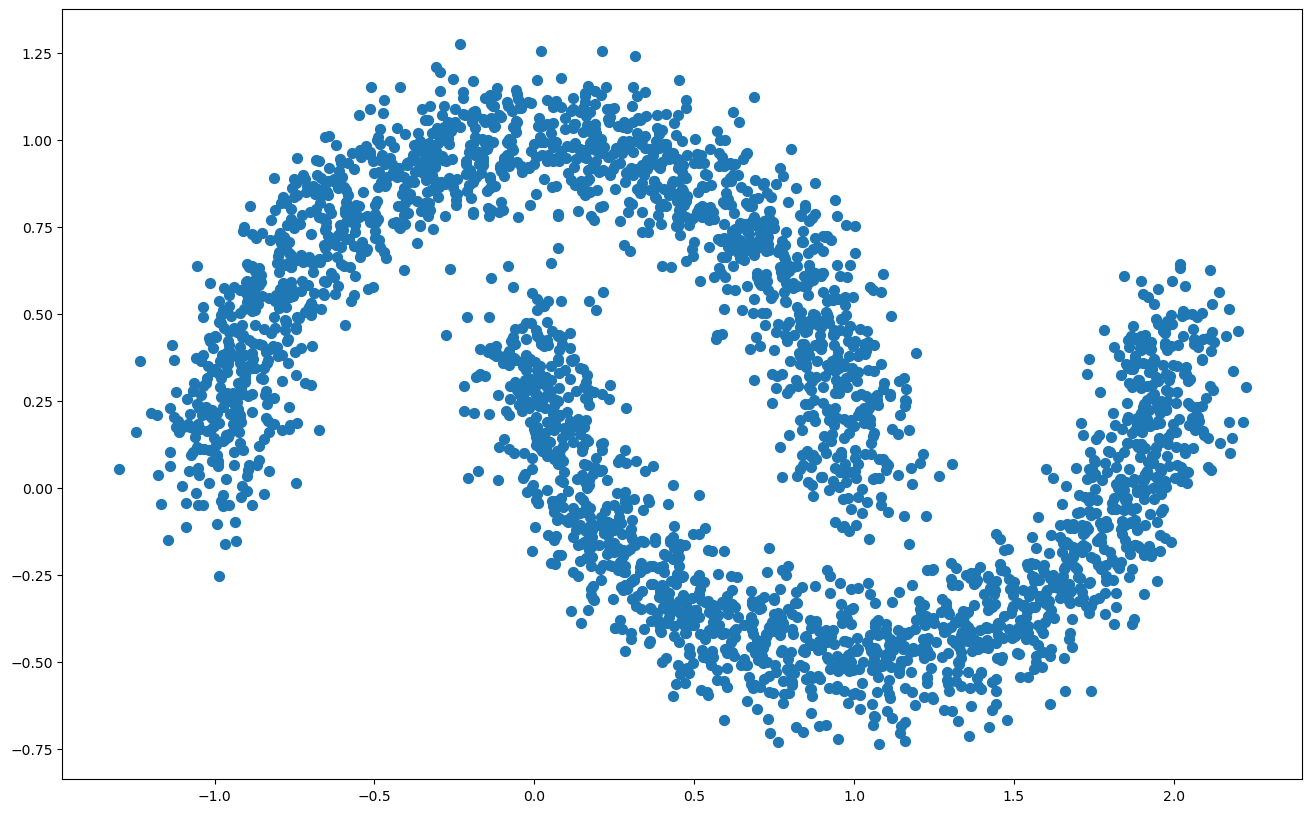

In [90]:
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt

X, y = make_moons(n_samples = 3000, noise = 0.1, random_state = 42)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X)
X_scaled = scaler.transform(X)

plt.figure(figsize = (16, 10))
plt.scatter(X[:, 0], X[:, 1], s = 50)
plt.show()

### Встроенный KMEANS

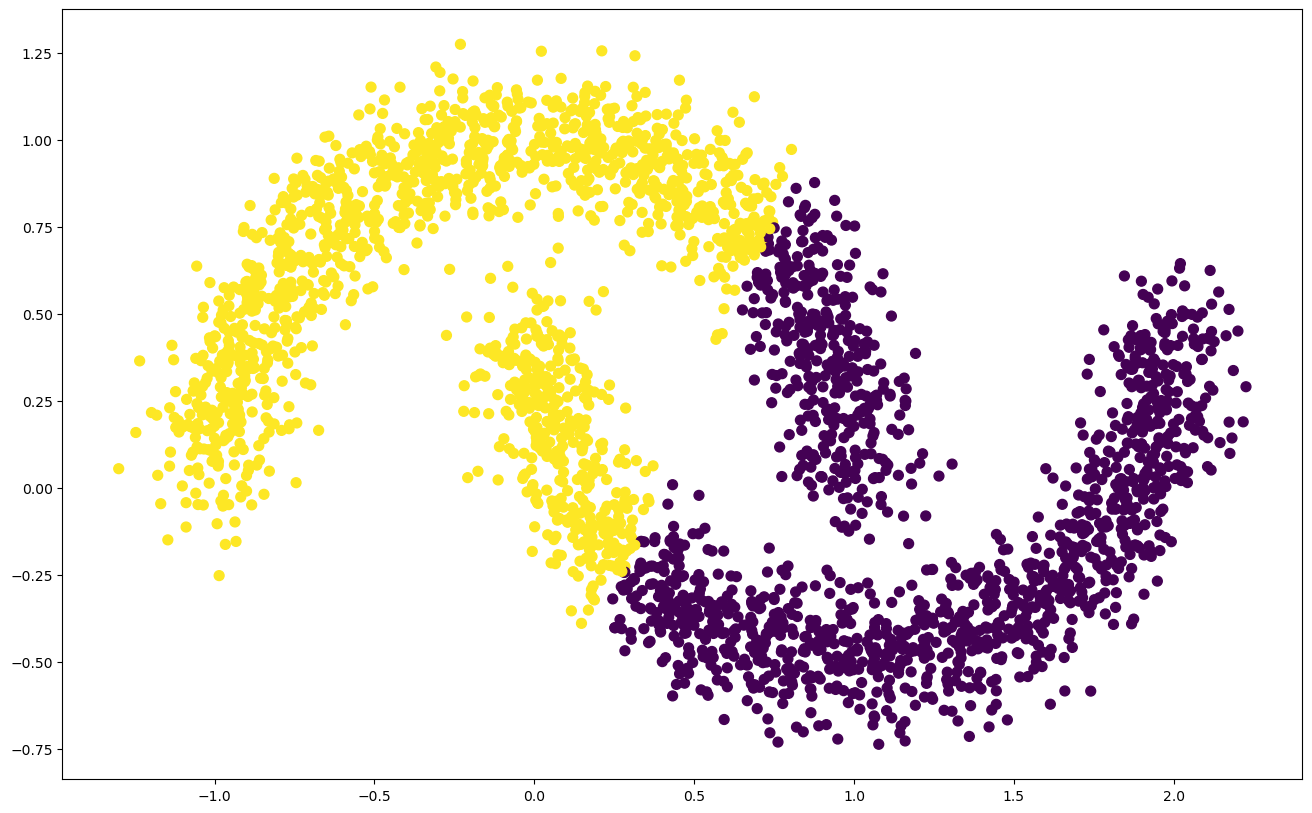

In [91]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters = 2)
kmeans.fit(X)
y_kmeans = kmeans.predict(X)

plt.figure(figsize = (16, 10))
plt.scatter(X[:, 0], X[:, 1], c = y_kmeans, s = 50)
plt.show()

### Моя реализация DBSCAN

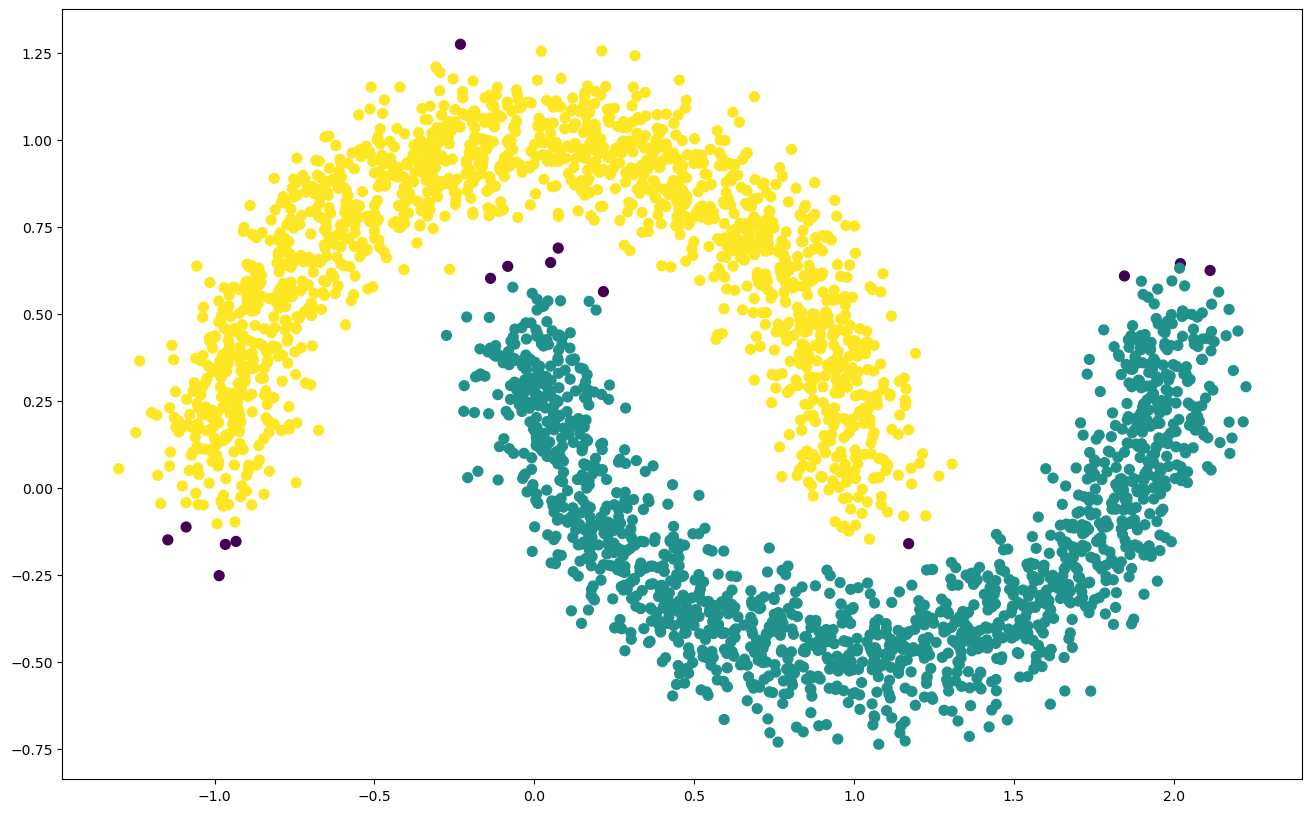

In [94]:
my_dbscan = MyDBSCAN(eps = 0.25, min_samples = 50)
y_my_dbscan = my_dbscan.fit_predict(X_scaled)

plt.figure(figsize = (16, 10))
plt.scatter(X[:, 0], X[:, 1], c = y_my_dbscan, s = 50)
plt.show()

### Встроенный DBSCAN

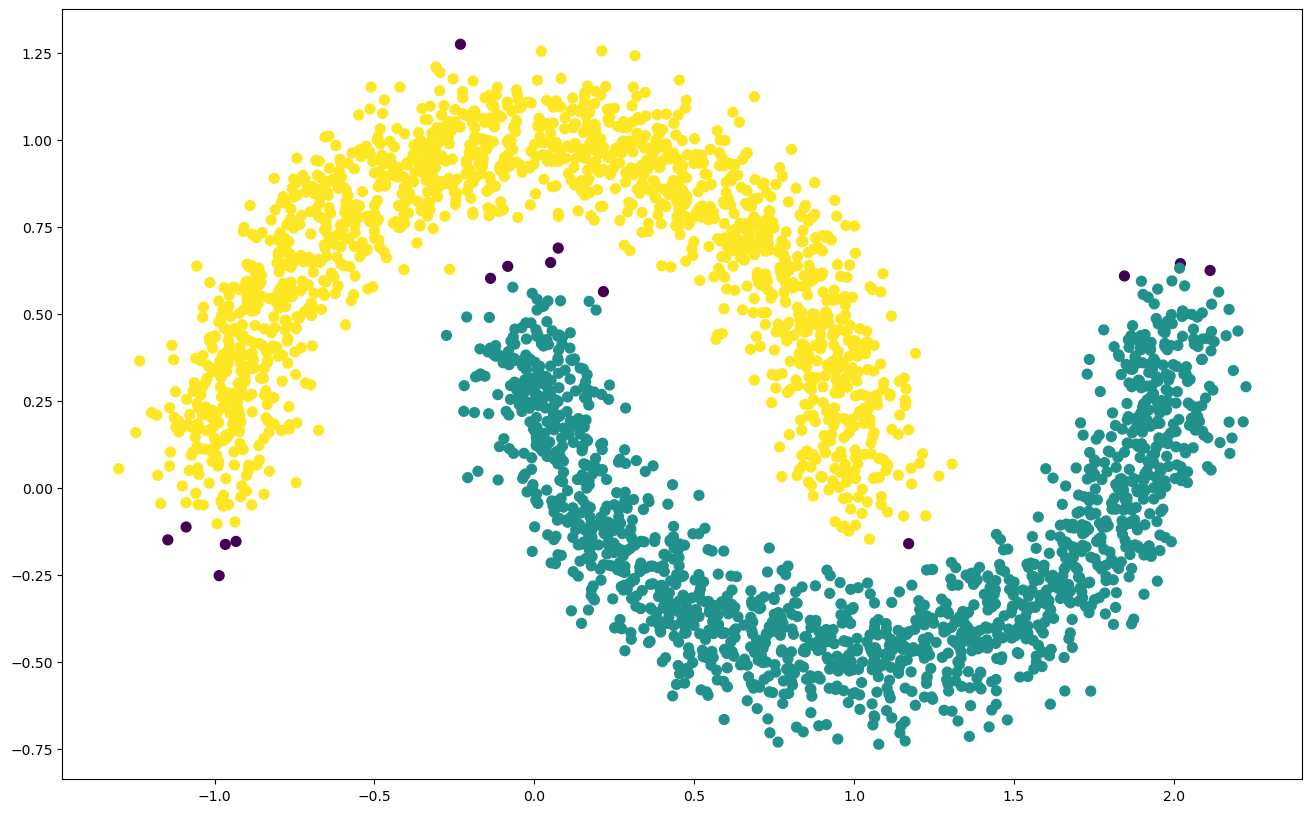

In [95]:
from sklearn.cluster import DBSCAN
y_dbscan = DBSCAN(eps = 0.25, min_samples = 50).fit_predict(X_scaled)

plt.figure(figsize = (16, 10))
plt.scatter(X[:, 0], X[:, 1], c = y_dbscan, s = 50)
plt.show()